In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [ ]:
# Define dataset paths
base_dir = "/content/drive/MyDrive/multi_diseases_dataset"  # Update this with your actual path
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

In [ ]:
# Image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
# Step 2: Image Preprocessing and Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 20% of training data used for validation
)

In [ ]:
# Data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

Found 687 images belonging to 4 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

Found 170 images belonging to 4 classes.


In [ ]:
test_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 374 images belonging to 4 classes.


In [ ]:
# Load MobileNetV2 as the base model
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Freeze the base model layers
base_model.trainable = False


In [ ]:
# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dense(train_generator.num_classes, activation="softmax")(x)  # Output layer

In [ ]:
# Define the final model
model = Model(inputs=base_model.input, outputs=x)


In [ ]:
# Compile the model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
# Train the model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 634s 29s/step - accuracy: 0.5324 - loss: 1.0621 - val_accuracy: 0.6824 - val_loss: 0.8508
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 935ms/step - accuracy: 0.8361 - loss: 0.4217 - val_accuracy: 0.6706 - val_loss: 0.7171
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 987ms/step - accuracy: 0.9117 - loss: 0.2662 - val_accuracy: 0.7412 - val_loss: 0.6872
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 998ms/step - accuracy: 0.8946 - loss: 0.2805 - val_accuracy: 0.7353 - val_loss: 0.7484
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 940ms/step - accuracy: 0.8909 - loss: 0.2964 - val_accuracy: 0.6824 - val_loss: 0.8108
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 993ms/step - accuracy: 0.9225 - loss: 0.1951 - val_accuracy: 0.7412 - val_loss: 0.8160
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 936ms/step - accuracy: 0.9136 - loss: 0.2148 - val_accuracy: 0.7118 - val_loss: 0.6736
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 992ms/step - accuracy: 0.9476 - loss: 0.1756 - val_accur

In [ ]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.7416 - loss: 0.8542
Test Accuracy: 0.7219


In [ ]:
import numpy as np

In [ ]:
# Get true labels and predictions for validation set
val_labels = val_generator.classes
val_pred = np.argmax(model.predict(val_generator), axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step


In [ ]:
# Get true labels and predictions for test set
test_labels = test_generator.classes
test_pred = np.argmax(model.predict(test_generator), axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 311ms/step


In [ ]:
# Get class names
class_names = list(test_generator.class_indices.keys())

In [ ]:
# Confusion matrix function
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
def plot_confusion_matrix(y_true, y_pred, dataset_type):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"Confusion Matrix - {dataset_type}")
    plt.show()

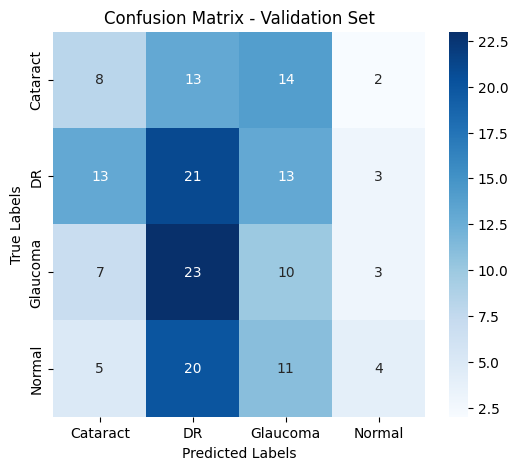

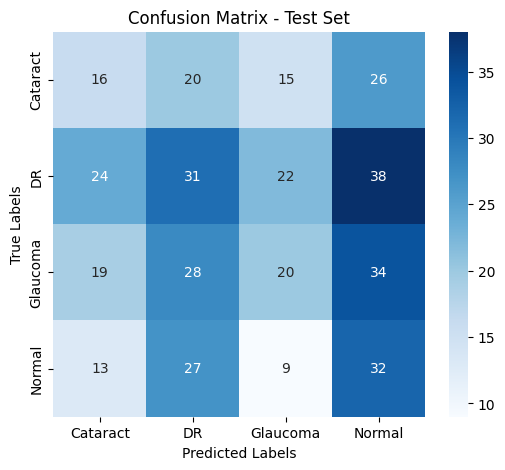

In [ ]:
# Plot Confusion Matrices
plot_confusion_matrix(val_labels, val_pred, "Validation Set")
plot_confusion_matrix(test_labels, test_pred, "Test Set")


In [ ]:
# Plot Accuracy & Loss Graphs
def plot_training_curves(history):
    plt.figure(figsize=(12, 5))

    # Accuracy Graph
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend()

    # Loss Graph
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()

    plt.show()


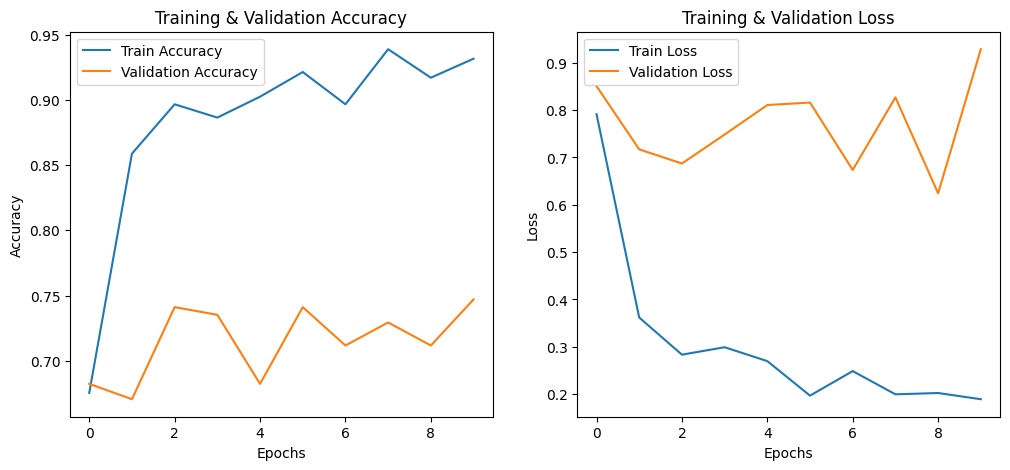

In [ ]:
# Plot accuracy and loss curves
plot_training_curves(history)


In [ ]:
# Step 6: Save Model
model.save("/content/drive/MyDrive/multi_diseases_dataset/multi_classifier.h5")

In [ ]:
##testing the model
import tensorflow as tf
import numpy as np
import cv2
import os

# Load the trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/multi_diseases_dataset/multi_classifier.h5")

# Load the class labels (must match the dataset folder structure)
class_labels = ['Cataract','Diabetic retinopathy','Glaucoma','Normal']  # Modify based on your dataset

# Function to preprocess an image
def preprocess_image(image_path):
    img = cv2.imread(image_path)  # Read image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    img = cv2.resize(img, (224, 224))  # Resize to match model input size
    img = img / 255.0  # Normalize pixel values
    img = np.expand_dims(img, axis=0)  # Expand dimensions to match model input
    return img

# Test on a new image
image_path = "/content/drive/MyDrive/multi_diseases_dataset/test/Normal/2705_right.jpg"  # Replace with your image path
input_image = preprocess_image(image_path)

# Make prediction
prediction = model.predict(input_image)
predicted_class = np.argmax(prediction, axis=1)[0]  # Get the class index

# Print the predicted waste category
print(f"Predicted Diseases Category: {class_labels[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Diseases Category: Normal


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
